Loan Analysis & Prediction Project
Introduction

This project focuses on analyzing customer loan data to discover patterns, generate insights, and build machine learning models that can predict whether a customer is likely to repay a loan.

The project includes:

Data Understanding
Data Cleaning & Preprocessing
Exploratory Data Analysis (EDA)
Data Visualization
Predictive Modeling

 # Import Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [78]:
df =pd.read_csv("train.csv")
df2= pd.read_csv("test.csv")

| Column Name            | المعنى بالعربي       | النوع                  | الشرح                                                                     |
| ---------------------- | -------------------- | ---------------------- | ------------------------------------------------------------------------- |
| `id`                   | رقم تعريفي           | Numerical (ID)         | رقم مميز لكل عميل أو طلب قرض، ملوش تأثير مباشر على الموديل وغالبًا بنحذفه |
| `annual_income`        | الدخل السنوي         | Numerical (Continuous) | إجمالي دخل الشخص في السنة                                                 |
| `debt_to_income_ratio` | نسبة الدين إلى الدخل | Numerical (Ratio)      | نسبة إجمالي الديون إلى الدخل السنوي (مؤشر مهم لمعرفة قدرة السداد)         |
| `credit_score`         | درجة الائتمان        | Numerical (Score)      | تقييم الجدارة الائتمانية للعميل (كل ما زاد أفضل)                          |
| `loan_amount`          | مبلغ القرض           | Numerical (Continuous) | قيمة القرض المطلوب                                                        |
| `interest_rate`        | نسبة الفائدة         | Numerical (Percentage) | الفائدة المفروضة على القرض                                                |
| `gender`               | النوع                | Categorical            | ذكر أو أنثى                                                               |
| `marital_status`       | الحالة الاجتماعية    | Categorical            | أعزب، متزوج، مطلق…                                                        |
| `education_level`      | المستوى التعليمي     | Categorical            | ثانوي، بكالوريوس، ماجستير…                                                |
| `employment_status`    | حالة التوظيف         | Categorical            | موظف، عاطل، عمل حر…                                                       |
| `loan_purpose`         | سبب القرض            | Categorical            | سيارة، منزل، تعليم، مشروع…                                                |
| `grade_subgrade`       | تصنيف القرض          | Categorical (Ordinal)  | تقييم القرض حسب المخاطرة (مثلاً A1 أفضل من B3)                            |
| `loan_paid_back`       | هل تم سداد القرض؟    | Target (Binary)        | 0 = لا، 1 = نعم (ده الـ Target بتاعك)                                     |


# Dataset Understanding

This dataset contains customer loan information.
The goal is to analyze customer data and predict whether the customer will pay back the loan or not.

In [79]:
df.head()   

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [80]:
df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

# Insights
The dataset contains customer loan information.
Some columns are numerical while others are categorical.
The target variable represents loan repayment status.

In [81]:
df.shape

(593994, 13)

In [82]:
df['loan_paid_back'].value_counts()

loan_paid_back
1.0    474494
0.0    119500
Name: count, dtype: int64

# Data Cleaning

- Removed duplicate rows
- Checked missing values
- Removed unnecessary columns like ID

In [83]:
df2.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64

In [84]:
df.drop_duplicates(inplace=True)    
df2.drop_duplicates(inplace=True)    

In [85]:
df.drop('id',axis=1,inplace=True)
df2.drop('id',axis=1,inplace=True)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   gender                593994 non-null  object 
 6   marital_status        593994 non-null  object 
 7   education_level       593994 non-null  object 
 8   employment_status     593994 non-null  object 
 9   loan_purpose          593994 non-null  object 
 10  grade_subgrade        593994 non-null  object 
 11  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 54.4+ MB


# Objective

Analyze data to identify trends, patterns, and relationships.

In [87]:
x =df.pivot_table(index='education_level', values='loan_paid_back', aggfunc='mean').reset_index().head(10)
x.sort_values(by='loan_paid_back', ascending=False, inplace=True)
x

,education_level,loan_paid_back
4,PhD,0.830067
1,High School,0.809698
3,Other,0.802789
2,Master's,0.802346
0,Bachelor's,0.788892


C:\Users\dell\AppData\Local\Temp\ipykernel_28440\1397667588.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=x ,x='education_level', y='loan_paid_back', palette='afmhot',order=x['education_level'])


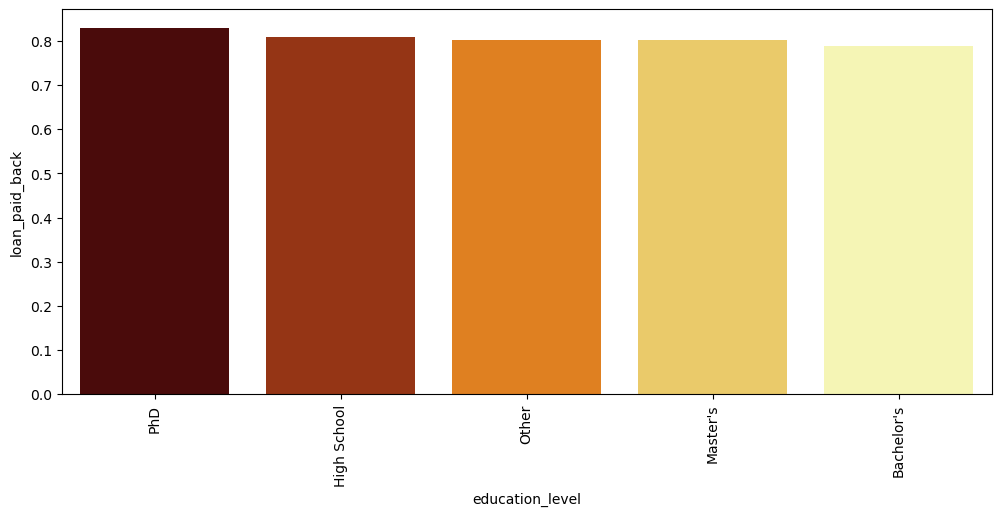

In [88]:
x =df.pivot_table(index='education_level', values='loan_paid_back', aggfunc='mean').reset_index()
x.sort_values(by='loan_paid_back', ascending=False, inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data=x ,x='education_level', y='loan_paid_back', palette='afmhot',order=x['education_level'])
plt.xticks (rotation=90)
plt.show()

In [89]:
x =df.pivot_table(index='gender', values='loan_paid_back', aggfunc='mean').reset_index()
x.sort_values(by='loan_paid_back', ascending=False, inplace=True)
x

,gender,loan_paid_back
0,Female,0.801708
1,Male,0.795752
2,Other,0.795333


C:\Users\dell\AppData\Local\Temp\ipykernel_28440\1056385764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=x ,x='gender', y='loan_paid_back', palette='afmhot',order=x['gender'])


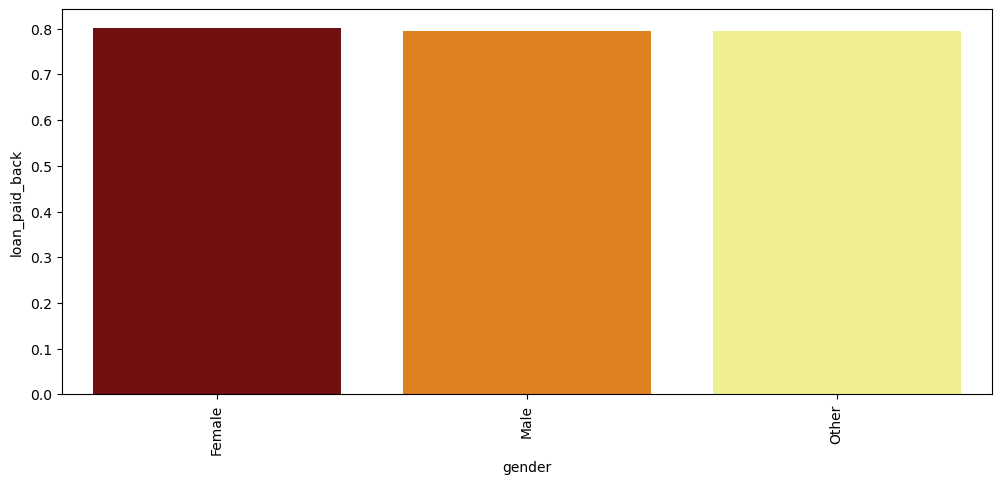

In [90]:
plt.figure(figsize=(12,5))
sns.barplot(data=x ,x='gender', y='loan_paid_back', palette='afmhot',order=x['gender'])
plt.xticks (rotation=90)
plt.show()

In [91]:
df['grade_subgrade'].value_counts().head(10)

grade_subgrade
C3    58695
C4    55957
C2    54443
C1    53363
C5    53317
D1    37029
D3    36694
D4    35097
D2    34432
D5    32101
Name: count, dtype: int64

In [92]:
x =df.pivot_table(index='grade_subgrade', values='loan_paid_back', aggfunc='sum').reset_index().head(10)
x.sort_values(by='loan_paid_back', ascending=False, inplace=True)
x

,grade_subgrade,loan_paid_back
6,B2,14218.0
5,B1,13144.0
7,B3,13091.0
9,B5,13020.0
8,B4,12930.0
4,A5,2335.0
2,A3,1974.0
1,A2,1923.0
3,A4,1628.0
0,A1,1524.0


C:\Users\dell\AppData\Local\Temp\ipykernel_28440\3742098924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=x ,x='grade_subgrade', y='loan_paid_back', palette='afmhot',order=x['grade_subgrade'])


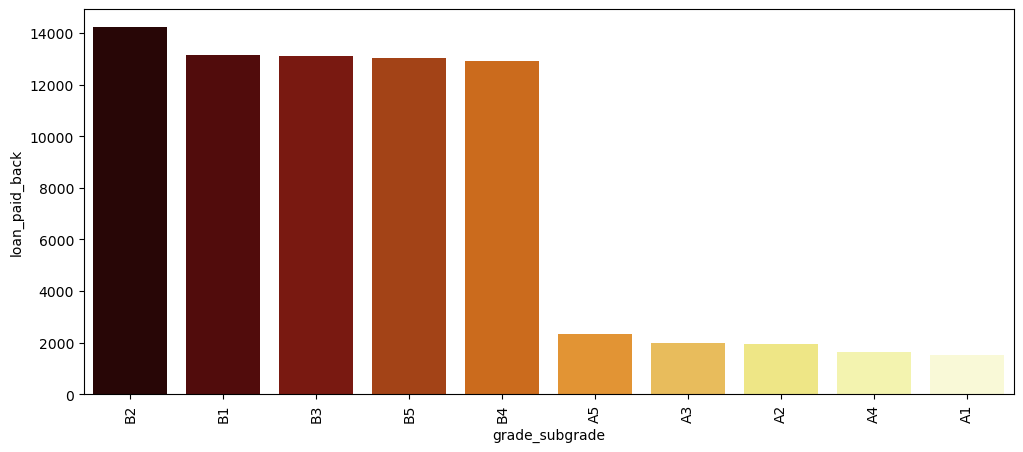

In [93]:
plt.figure(figsize=(12,5))
sns.barplot(data=x ,x='grade_subgrade', y='loan_paid_back', palette='afmhot',order=x['grade_subgrade'])
plt.xticks (rotation=90)
plt.show()

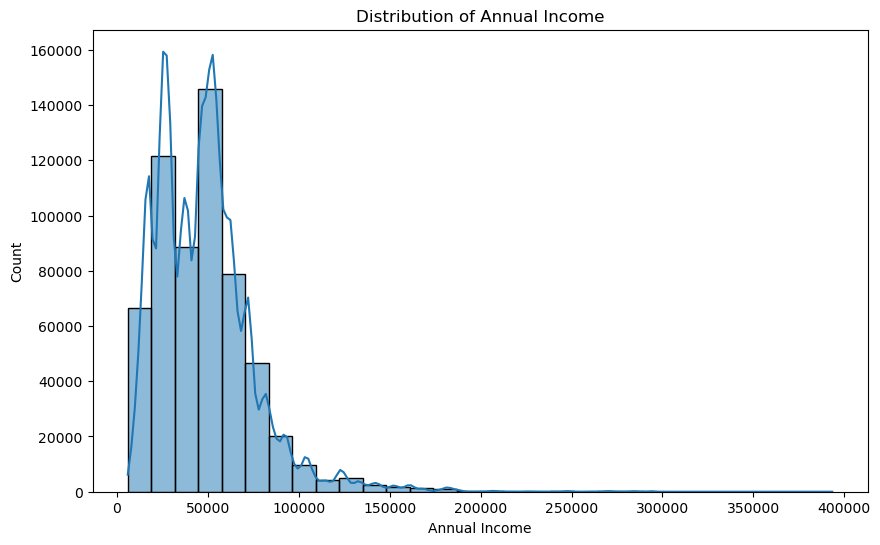

In [94]:
plt.figure(figsize=(10,6))
sns.histplot(df['annual_income'], bins=30, kde=True)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Count')
plt.show()


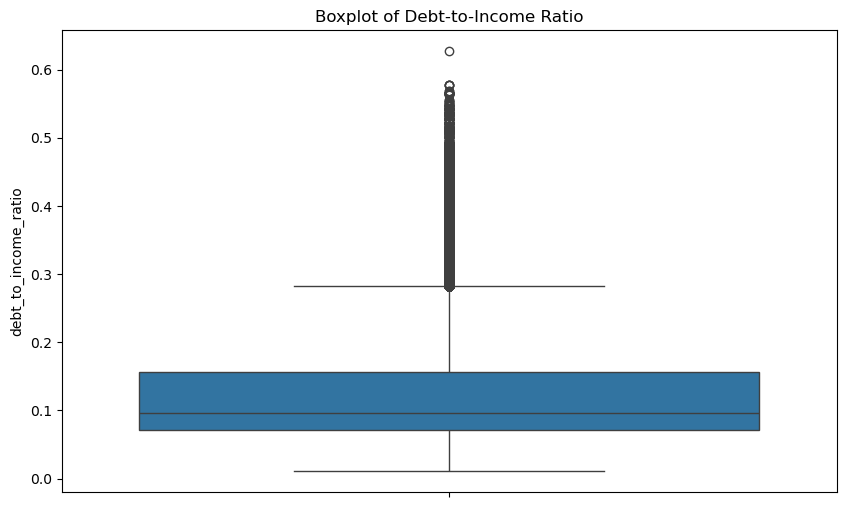

In [95]:
plt.figure(figsize=(10,6))
sns.boxplot(y='debt_to_income_ratio',data=df)
plt.title('Boxplot of Debt-to-Income Ratio')
plt.show()


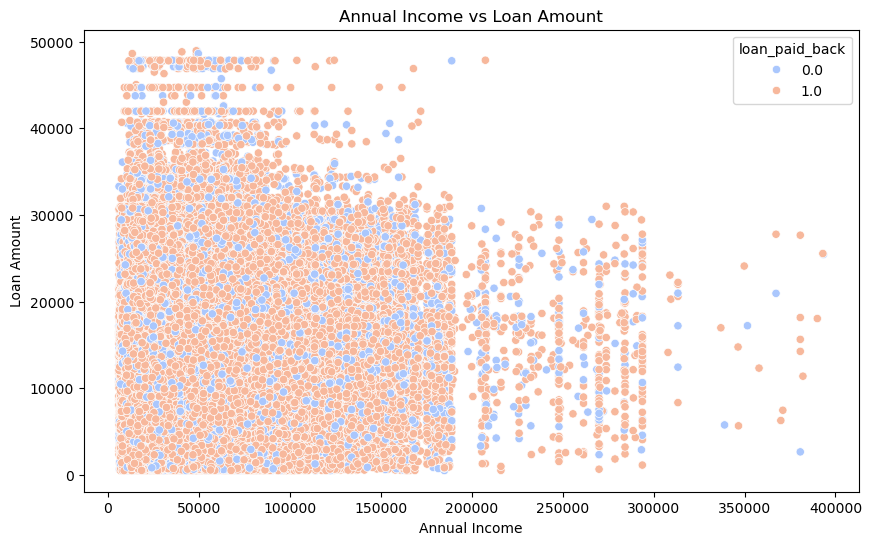

In [96]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='annual_income', y='loan_amount', hue='loan_paid_back', data=df, palette='coolwarm')
plt.title('Annual Income vs Loan Amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.show()


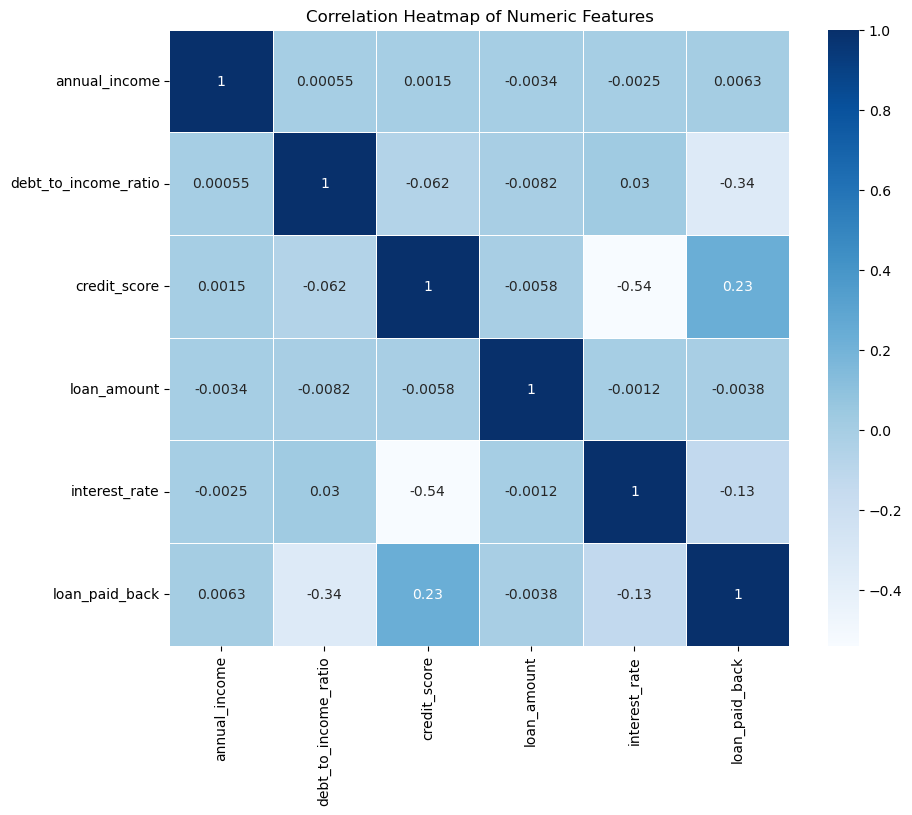

In [97]:
numeric_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate','loan_paid_back']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


In [98]:
x =df.pivot_table(index='credit_score', values='loan_amount', aggfunc='sum').reset_index().head(10)
x.sort_values(by='credit_score', ascending=False, inplace=True)
x

,credit_score,loan_amount
9,447,29861.35
8,446,25993.57
7,445,51394.83
6,441,27251.64
5,440,7703.57
4,439,23490.78
3,437,64259.16
2,435,36340.03
1,431,25261.00
0,395,39782.46


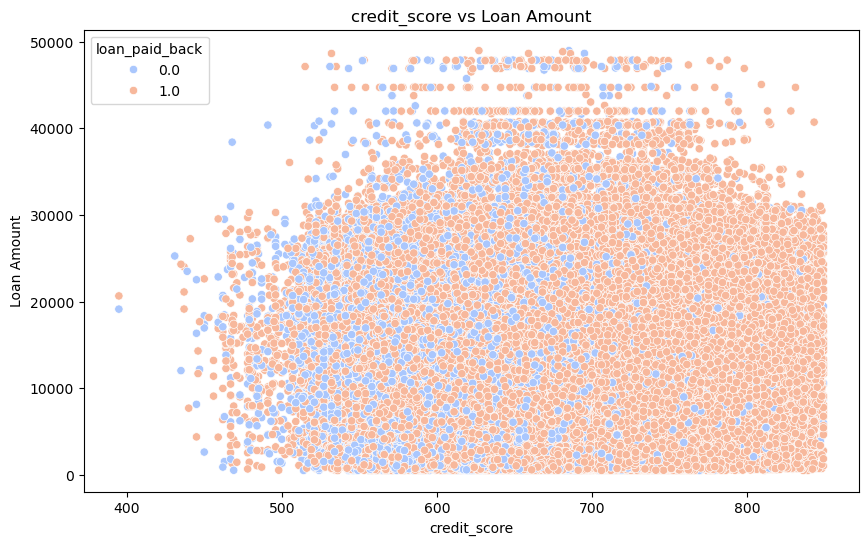

In [99]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='credit_score', y='loan_amount', hue='loan_paid_back', data=df, palette='coolwarm')
plt.title('credit_score vs Loan Amount')
plt.xlabel('credit_score')
plt.ylabel('Loan Amount')
plt.show()


In [100]:
x =df.pivot_table(index='loan_purpose', values='loan_amount', aggfunc='mean').reset_index()
x.sort_values(by='loan_amount', ascending=False, inplace=True)
x

,loan_purpose,loan_amount
6,Other,15129.139350
2,Debt consolidation,15058.305519
5,Medical,15010.542406
7,Vacation,14972.701033
4,Home,14933.436416
0,Business,14928.274828
3,Education,14916.961356
1,Car,14886.041786


C:\Users\dell\AppData\Local\Temp\ipykernel_28440\209629904.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=x ,x='loan_purpose', y='loan_amount', palette='afmhot',order=x['loan_purpose'])


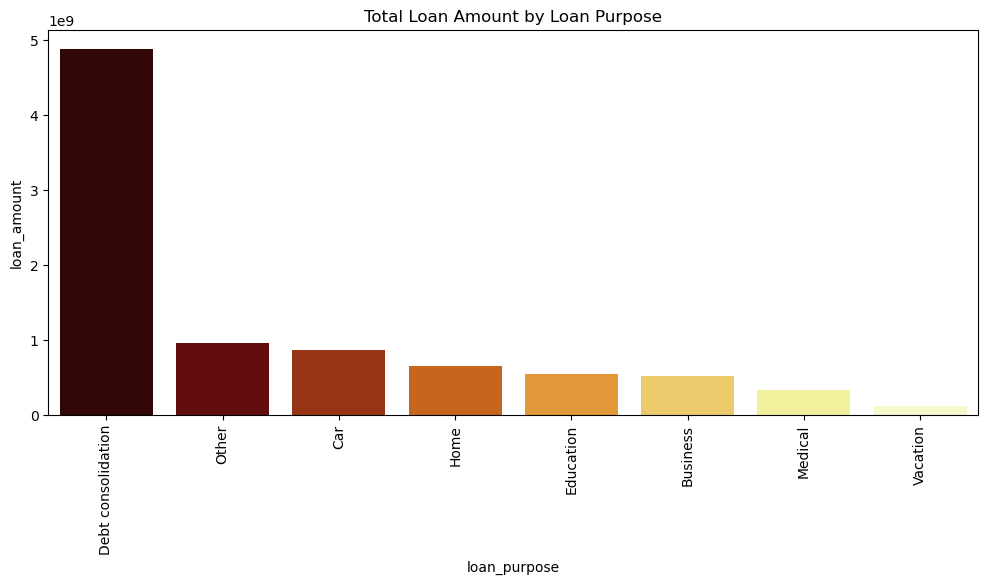

In [101]:
x =df.pivot_table(index='loan_purpose', values='loan_amount', aggfunc='sum').reset_index()
x.sort_values(by='loan_amount', ascending=False, inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data=x ,x='loan_purpose', y='loan_amount', palette='afmhot',order=x['loan_purpose'])
plt.title('Total Loan Amount by Loan Purpose')
plt.xticks (rotation=90)
plt.show()

# Insights
Most customers fall into specific loan categories.
Visualizations help identify trends and outliers clearly.

In [102]:
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [103]:
df.describe(include='O')

,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
count,593994,593994,593994,593994,593994,593994
unique,3,4,5,5,8,30
top,Female,Single,Bachelor's,Employed,Debt consolidation,C3
freq,306175,288843,279606,450645,324695,58695


In [104]:
df['employment_status'].value_counts()

employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

In [105]:
df= df[df['gender'] != 'Other']
df2= df2[df2['gender'] != 'Other']


In [106]:
from math import pi
from sklearn.preprocessing import LabelEncoder
import pickle
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df2['gender'] = le.transform(df2['gender'])
with open('label_encoder.pkl', 'wb') as f:
        pickle.dump(le, f)


In [107]:
df.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [108]:

from sklearn.preprocessing import OneHotEncoder

ohe_emp = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_emp.fit(df[['employment_status']])

train_emp = ohe_emp.transform(df[['employment_status']])
train_emp_df = pd.DataFrame(train_emp, columns=ohe_emp.get_feature_names_out(['employment_status']))

df = pd.concat([df, train_emp_df], axis=1)

test_emp = ohe_emp.transform(df2[['employment_status']])
test_emp_df = pd.DataFrame(test_emp, columns=ohe_emp.get_feature_names_out(['employment_status']))
df2 = pd.concat([df2, test_emp_df], axis=1)

with open('onehot1.pkl', 'wb') as f:
    pickle.dump(ohe_emp, f)


In [109]:
df.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [110]:
ohe_edu = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_edu.fit(df[['education_level']])

train_edu = ohe_edu.transform(df[['education_level']])
train_edu_df = pd.DataFrame(train_edu, columns=ohe_edu.get_feature_names_out(['education_level']))

df = pd.concat([df, train_edu_df], axis=1)

test_edu = ohe_edu.transform(df2[['education_level']])
test_edu_df = pd.DataFrame(test_edu, columns=ohe_edu.get_feature_names_out(['education_level']))
df2 = pd.concat([df2, test_edu_df], axis=1)

with open('onehot.pkl', 'wb') as f:
    pickle.dump(ohe_edu, f)


In [111]:
df.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [112]:
df.isna().sum()

annual_income                      0
debt_to_income_ratio               0
credit_score                       0
loan_amount                        0
interest_rate                      0
gender                             0
marital_status                     0
education_level                    0
employment_status                  0
loan_purpose                       0
grade_subgrade                     0
loan_paid_back                     0
employment_status_Employed         0
employment_status_Retired          0
employment_status_Self-employed    0
employment_status_Student          0
employment_status_Unemployed       0
education_level_Bachelor's         0
education_level_High School        0
education_level_Master's           0
education_level_Other              0
education_level_PhD                0
dtype: int64

In [113]:
df.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [114]:
df.drop(columns=['employment_status'],axis=1,inplace=True)
df2.drop(columns=['employment_status'],axis=1,inplace=True)
df.drop(columns=['education_level'],axis=1,inplace=True)
df2.drop(columns=['education_level'],axis=1,inplace=True)

In [115]:
df.isna().sum()

annual_income                      0
debt_to_income_ratio               0
credit_score                       0
loan_amount                        0
interest_rate                      0
gender                             0
marital_status                     0
loan_purpose                       0
grade_subgrade                     0
loan_paid_back                     0
employment_status_Employed         0
employment_status_Retired          0
employment_status_Self-employed    0
employment_status_Student          0
employment_status_Unemployed       0
education_level_Bachelor's         0
education_level_High School        0
education_level_Master's           0
education_level_Other              0
education_level_PhD                0
dtype: int64

In [116]:
df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,loan_purpose,grade_subgrade,loan_paid_back,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD
0,29367.99,0.084,736,2528.42,13.67,0,Single,Other,C3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,22108.02,0.166,636,4593.10,12.92,1,Married,Debt consolidation,D3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,49566.20,0.097,694,17005.15,9.76,1,Single,Debt consolidation,C5,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,46858.25,0.065,533,4682.48,16.10,0,Single,Debt consolidation,F1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,25496.70,0.053,665,12184.43,10.21,1,Married,Other,D1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [117]:
df2.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD
count,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000,252927.000000
mean,48229.261214,0.120595,681.059266,15017.444176,12.351663,0.480166,0.758954,0.027759,0.088480,0.019859,0.104947,0.471215,0.309046,0.156389,0.044459,0.018891
std,26720.300183,0.068582,55.621004,6922.688755,2.017132,0.499607,0.427719,0.164282,0.283992,0.139518,0.306486,0.499172,0.462101,0.363224,0.206114,0.136140
min,6011.770000,0.011000,395.000000,500.050000,3.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27931.060000,0.072000,647.000000,10252.100000,10.980000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46518.890000,0.096000,683.000000,15000.800000,12.370000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,61148.920000,0.156000,719.000000,18846.980000,13.690000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,380653.940000,0.627000,849.000000,48959.260000,21.290000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [118]:
df.describe(include='O')

,marital_status,loan_purpose,grade_subgrade
count,590266,590266,590266
unique,4,8,30
top,Single,Debt consolidation,C3
freq,287018,322692,58300


In [119]:
x= df.drop('loan_paid_back',axis=1)
y= df['loan_paid_back']

In [120]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [121]:
from category_encoders import TargetEncoder
encoder = TargetEncoder()
x_train['grade_subgrade'] = encoder.fit_transform(x_train['grade_subgrade'], y_train)
x_test['grade_subgrade'] = encoder.transform(x_test['grade_subgrade'])
with open('target1.pkl', 'wb') as f:
        pickle.dump(encoder, f)

In [122]:
from category_encoders import TargetEncoder
encoder = TargetEncoder()
x_train['loan_purpose'] = encoder.fit_transform(x_train['loan_purpose'], y_train)
x_test['loan_purpose'] = encoder.transform(x_test['loan_purpose'])
with open('target2.pkl', 'wb') as f:
        pickle.dump(encoder, f)

In [123]:
from category_encoders import TargetEncoder
encoder = TargetEncoder()
x_train['marital_status'] = encoder.fit_transform(x_train['marital_status'], y_train)
x_test['marital_status'] = encoder.transform(x_test['marital_status'])
with open('target3.pkl', 'wb') as f:
        pickle.dump(encoder, f)

In [124]:
x_train.drop(columns=['grade_subgrade','loan_purpose','marital_status'],axis=1,inplace=True)
x_test.drop(columns=['grade_subgrade','loan_purpose','marital_status'],axis=1,inplace=True)
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)


In [125]:
x_train.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD
count,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000,472212.000000
mean,48213.277730,0.120728,680.918708,15027.121493,12.355401,0.481288,0.758892,0.027568,0.088329,0.020105,0.105105,0.471879,0.308912,0.156188,0.044652,0.018369
std,26733.188939,0.068597,55.446940,6928.939336,2.008540,0.499650,0.427756,0.163732,0.283773,0.140361,0.306689,0.499209,0.462045,0.363034,0.206538,0.134281
min,6026.310000,0.011000,431.000000,500.090000,3.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27897.190000,0.072000,646.000000,10279.220000,10.990000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46552.490000,0.096000,682.000000,15000.800000,12.370000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60983.420000,0.157000,719.000000,18888.640000,13.680000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [126]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(x_train)
# X_test_scaled = scaler.transform(x_test)

# x_train = pd.DataFrame(X_train_scaled, columns=x_train.columns)
# x_test = pd.DataFrame(X_test_scaled, columns=x_test.columns)

# x_train.columns = x_train.columns.astype(str)
# x_test.columns = x_test.columns.astype(str)

# print(x_train.head())
# print(x_train.columns)

# with open('scaler.pkl', 'wb') as f:
#         pickle.dump(scaler, f)


Build machine learning models to predict loan repayment.

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [128]:

models = {


    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1,class_weight='balanced'),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    #"SVC": SVC(probability=True, random_state=1),

    "Decision Tree": DecisionTreeClassifier(random_state=100,class_weight='balanced',),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(n_estimators=100,max_depth=8, random_state=42,class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42,class_weight='balanced'),

    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=100,max_depth=3,learning_rate=0.1,n_estimators=100),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1,class_weight='balanced'),

    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=100, use_label_encoder=False,learning_rate=0.05,n_estimators=100,max_depth=4),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=100, max_depth=3,learning_rate=0.1,n_estimators=100),
    "LightGBM": LGBMClassifier(random_state=100,max_depth=3,learning_rate=0.1,n_estimators=100)
}

In [129]:
y_test.head()


178611    0.0
25587     1.0
87083     1.0
64146     1.0
194636    1.0
Name: loan_paid_back, dtype: float64

# Stopping execution to avoid re-running time-consuming model training

In [130]:
raise SystemExit("Notebook execution stopped intentionally.")

SystemExit: Notebook execution stopped intentionally.

e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\IPython\core\interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


  0%|          | 0/12 [00:00<?, ?it/s]


Confusion Matrix:
 [[18301  5447]
 [11026 83280]]


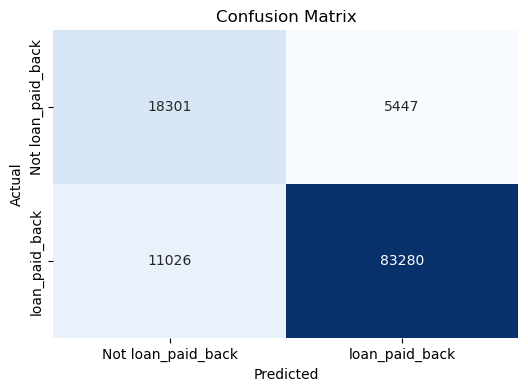


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.62      0.77      0.69     23748
    loan_paid_back       0.94      0.88      0.91     94306

          accuracy                           0.86    118054
         macro avg       0.78      0.83      0.80    118054
      weighted avg       0.88      0.86      0.87    118054

ROC-AUC: 0.9114025024690267


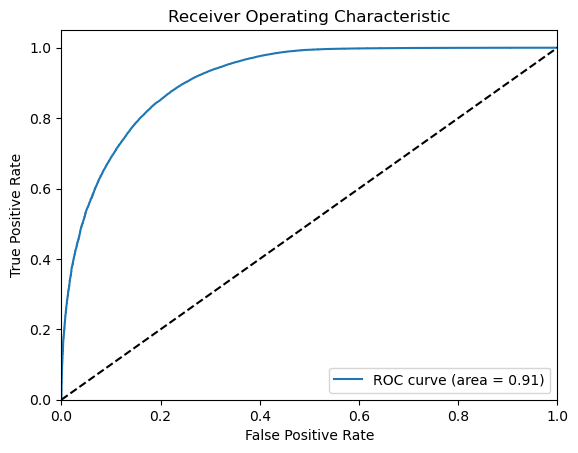

PR AUC: 0.9714205928488566


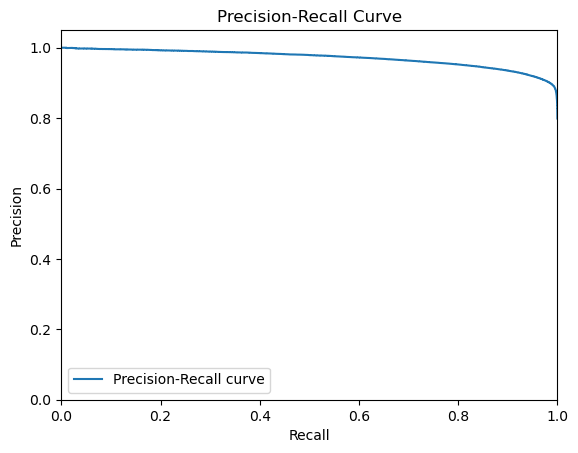

  8%|▊         | 1/12 [00:02<00:22,  2.07s/it]


Confusion Matrix:
 [[14503  9245]
 [ 3538 90768]]


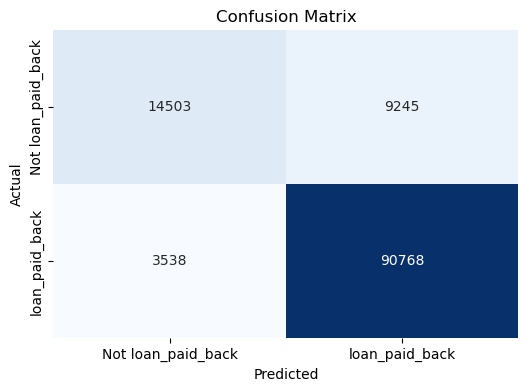


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.80      0.61      0.69     23748
    loan_paid_back       0.91      0.96      0.93     94306

          accuracy                           0.89    118054
         macro avg       0.86      0.79      0.81    118054
      weighted avg       0.89      0.89      0.89    118054

ROC-AUC: 0.8582808095304746


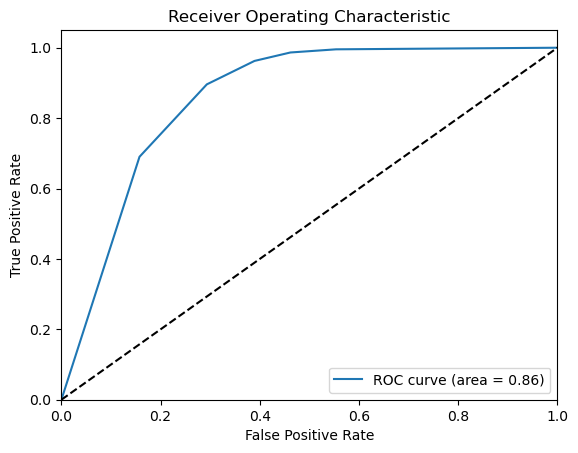

PR AUC: 0.9361353914971087


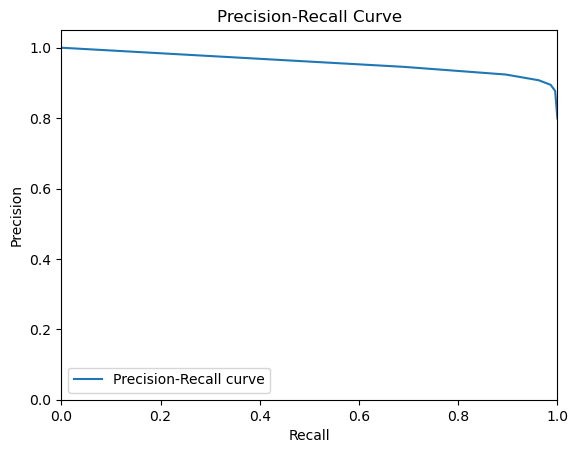

 17%|█▋        | 2/12 [06:05<35:46, 214.68s/it]


Confusion Matrix:
 [[15173  8575]
 [ 8764 85542]]


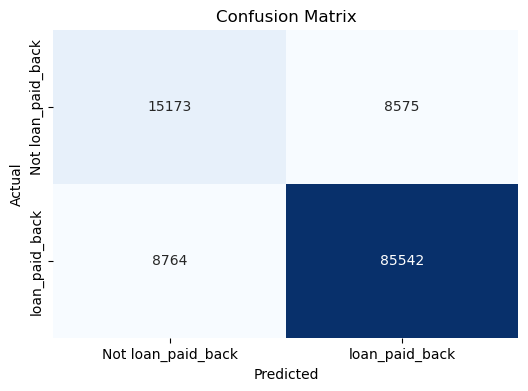


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.63      0.64      0.64     23748
    loan_paid_back       0.91      0.91      0.91     94306

          accuracy                           0.85    118054
         macro avg       0.77      0.77      0.77    118054
      weighted avg       0.85      0.85      0.85    118054

ROC-AUC: 0.7729927203171598


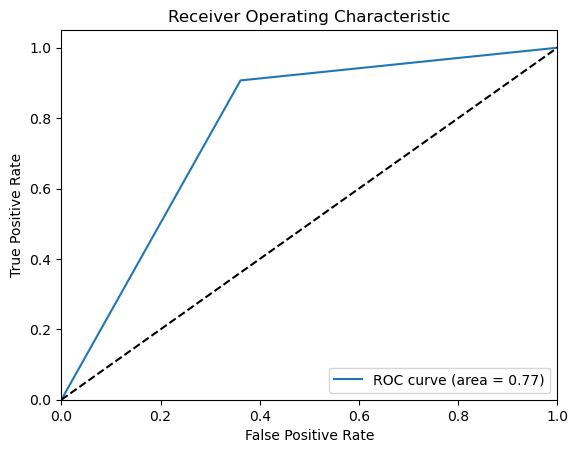

PR AUC: 0.898662682291212


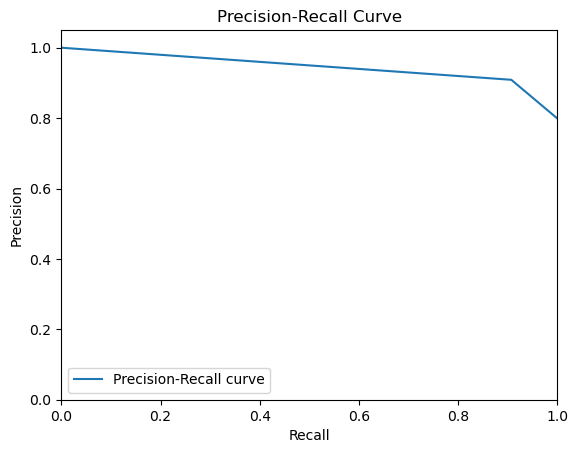

 25%|██▌       | 3/12 [06:17<18:17, 121.92s/it]


Confusion Matrix:
 [[14628  9120]
 [ 3167 91139]]


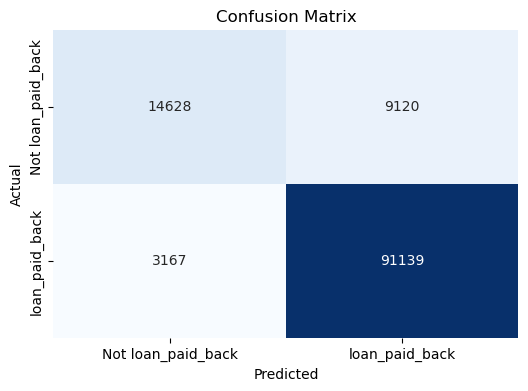


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.82      0.62      0.70     23748
    loan_paid_back       0.91      0.97      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.87      0.79      0.82    118054
      weighted avg       0.89      0.90      0.89    118054

ROC-AUC: 0.8881031892456381


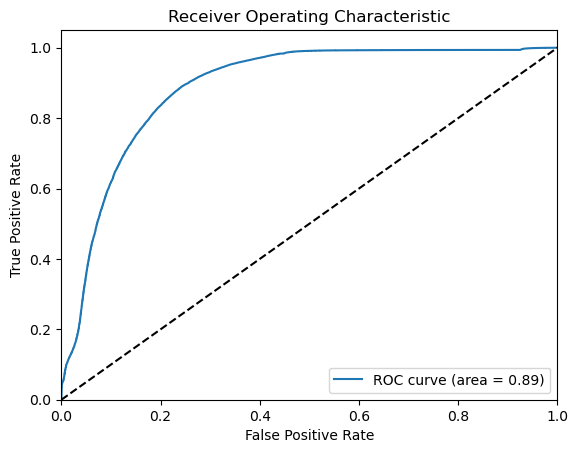

PR AUC: 0.9567766613894484


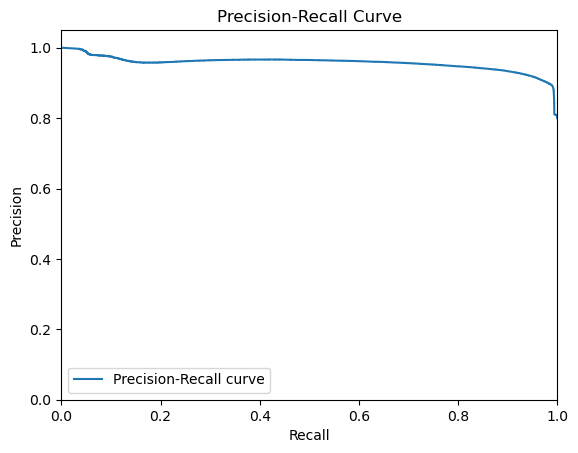

 33%|███▎      | 4/12 [06:19<09:56, 74.55s/it] 


Confusion Matrix:
 [[18346  5402]
 [10288 84018]]


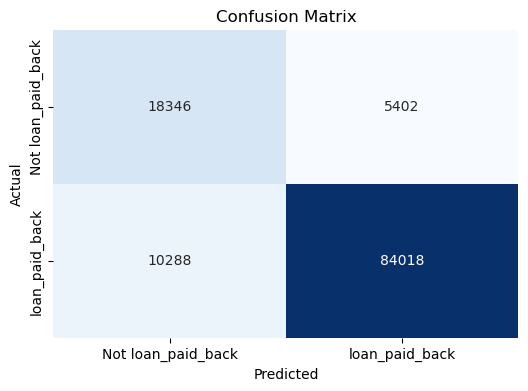


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.64      0.77      0.70     23748
    loan_paid_back       0.94      0.89      0.91     94306

          accuracy                           0.87    118054
         macro avg       0.79      0.83      0.81    118054
      weighted avg       0.88      0.87      0.87    118054

ROC-AUC: 0.9125467481634878


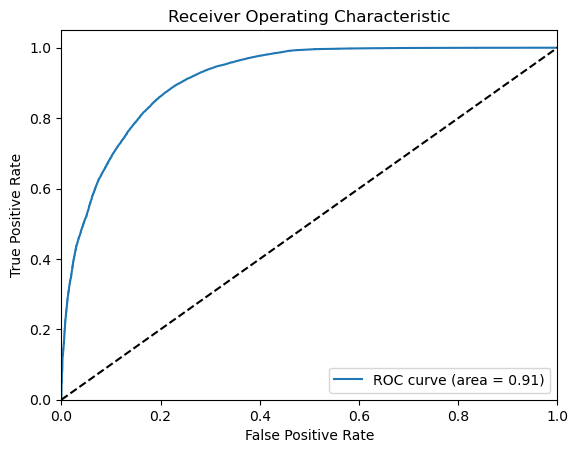

PR AUC: 0.9714049974768642


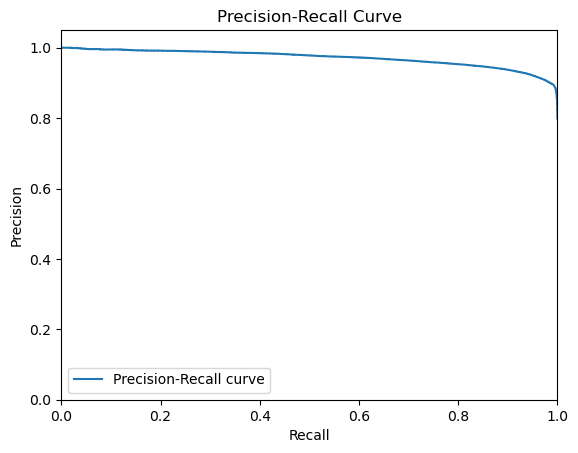

 42%|████▏     | 5/12 [07:31<08:37, 73.89s/it]


Confusion Matrix:
 [[14018  9730]
 [ 2069 92237]]


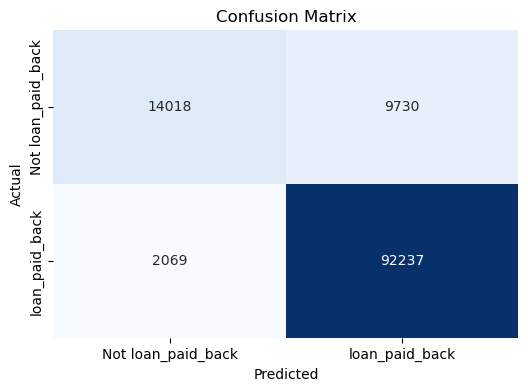


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.87      0.59      0.70     23748
    loan_paid_back       0.90      0.98      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.89      0.78      0.82    118054
      weighted avg       0.90      0.90      0.89    118054

ROC-AUC: 0.9047053322642322


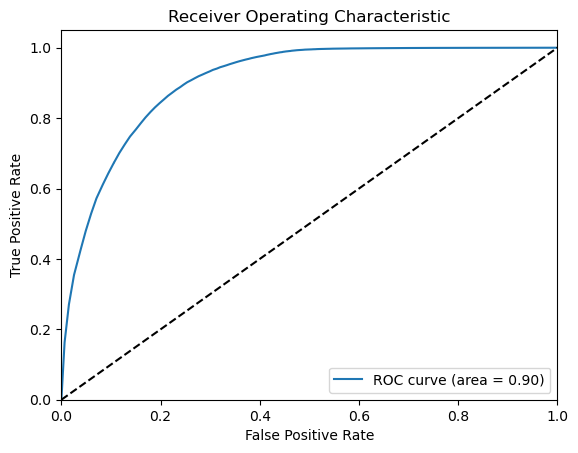

PR AUC: 0.9661865914434988


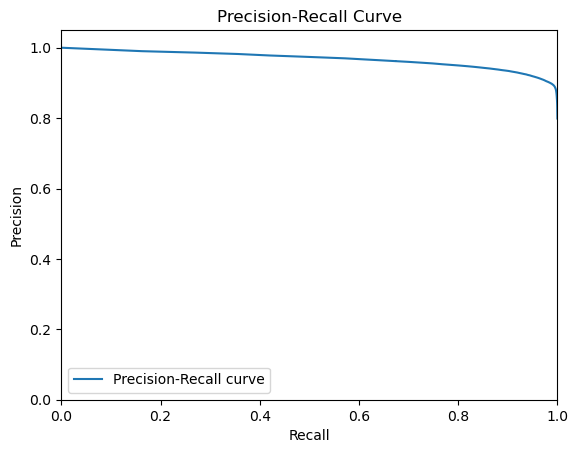

 50%|█████     | 6/12 [09:41<09:17, 92.94s/it]


Confusion Matrix:
 [[14084  9664]
 [ 2100 92206]]


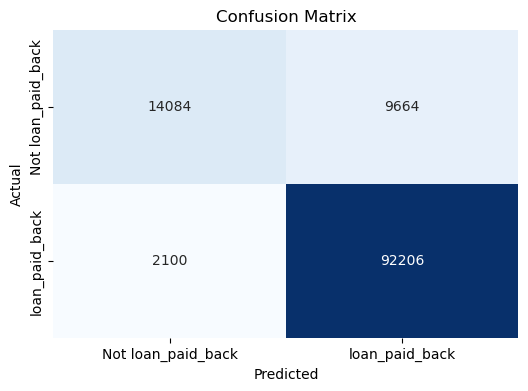


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.87      0.59      0.71     23748
    loan_paid_back       0.91      0.98      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.89      0.79      0.82    118054
      weighted avg       0.90      0.90      0.89    118054

ROC-AUC: 0.9084325492623594


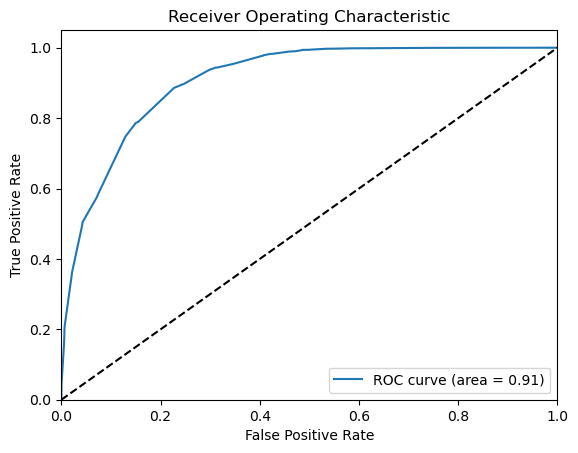

PR AUC: 0.9666311415082972


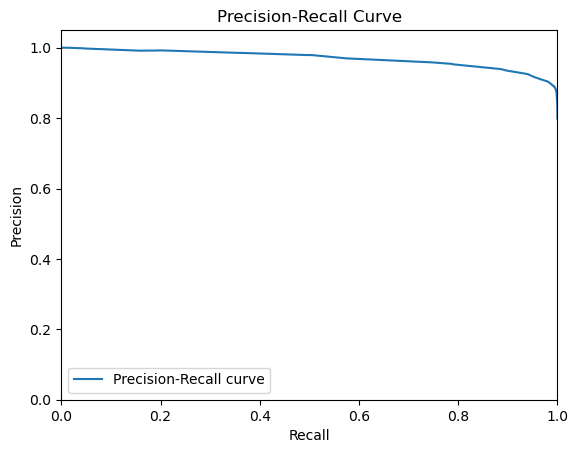

 58%|█████▊    | 7/12 [12:58<10:34, 126.90s/it]


Confusion Matrix:
 [[14119  9629]
 [ 1774 92532]]


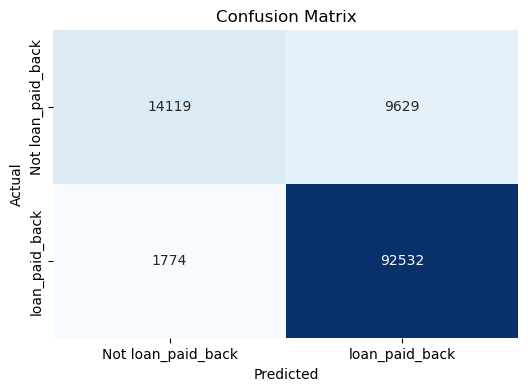


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.89      0.59      0.71     23748
    loan_paid_back       0.91      0.98      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.90      0.79      0.83    118054
      weighted avg       0.90      0.90      0.90    118054

ROC-AUC: 0.9163660992235608


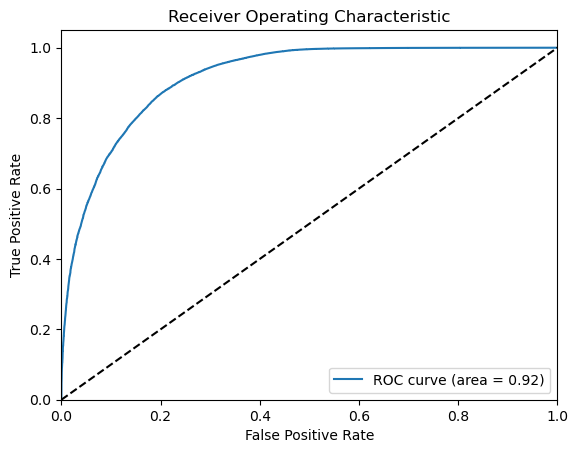

PR AUC: 0.9730435380302839


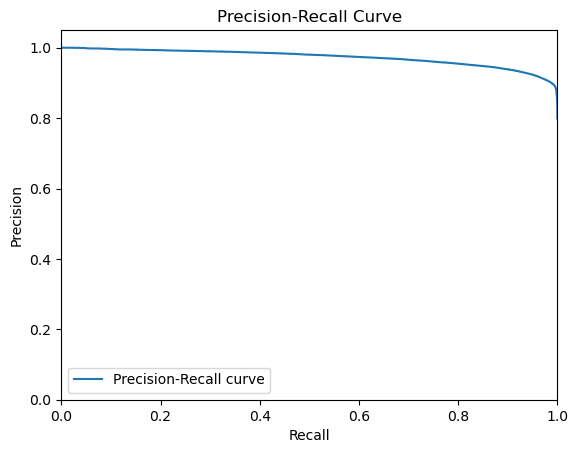

 67%|██████▋   | 8/12 [14:56<08:16, 124.02s/it]


Confusion Matrix:
 [[18830  4918]
 [11011 83295]]


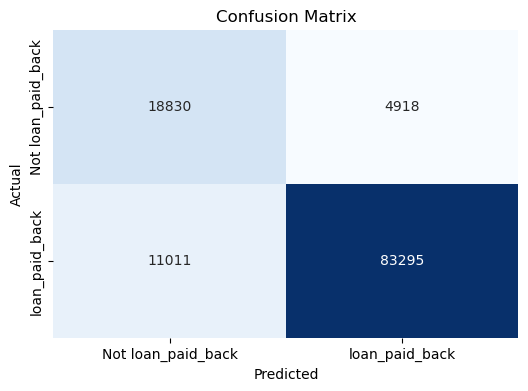


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.63      0.79      0.70     23748
    loan_paid_back       0.94      0.88      0.91     94306

          accuracy                           0.87    118054
         macro avg       0.79      0.84      0.81    118054
      weighted avg       0.88      0.87      0.87    118054

ROC-AUC: 0.9200821857809904


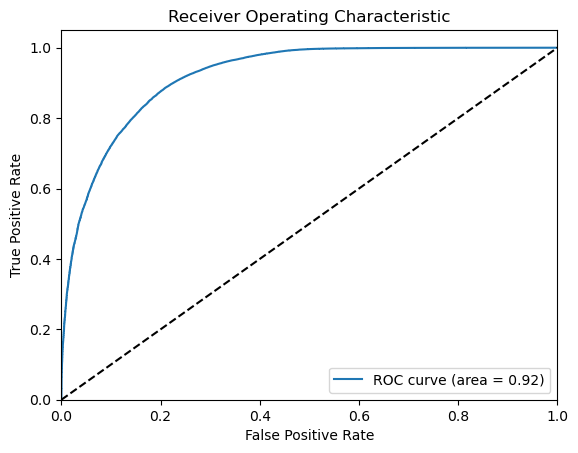

PR AUC: 0.9743919697372923


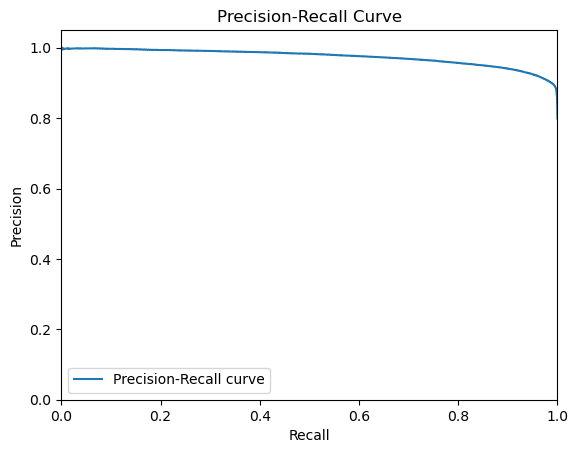

 75%|███████▌  | 9/12 [15:04<04:23, 87.82s/it] e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:37:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[13569 10179]
 [ 1334 92972]]


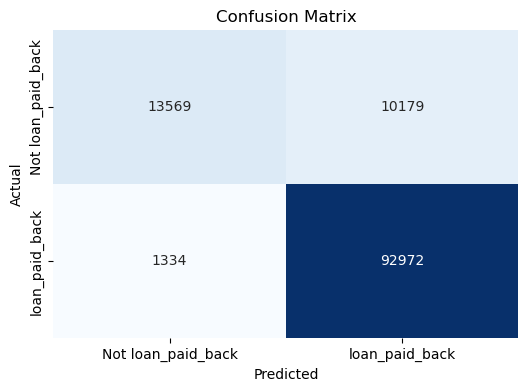


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.91      0.57      0.70     23748
    loan_paid_back       0.90      0.99      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.91      0.78      0.82    118054
      weighted avg       0.90      0.90      0.89    118054

ROC-AUC: 0.9154878285314502


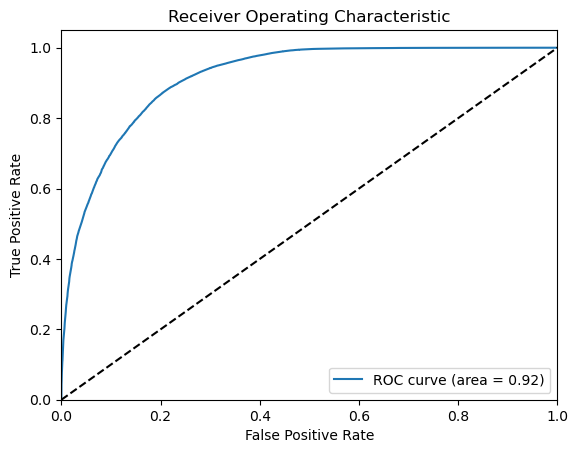

PR AUC: 0.9726427276770231


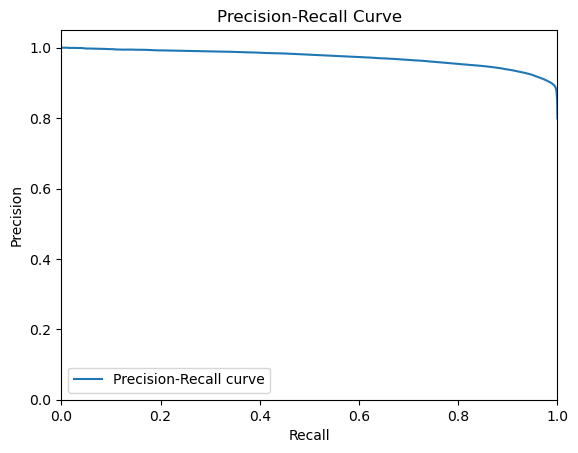

 83%|████████▎ | 10/12 [15:08<02:03, 61.84s/it]


Confusion Matrix:
 [[14097  9651]
 [ 1839 92467]]


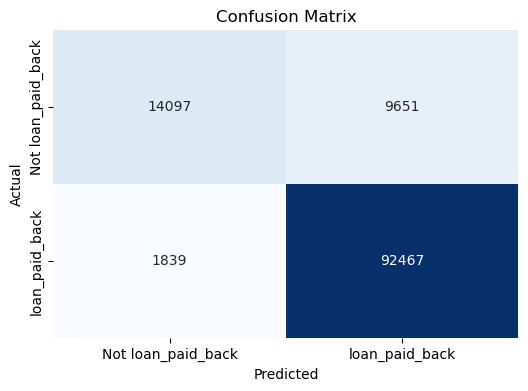


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.88      0.59      0.71     23748
    loan_paid_back       0.91      0.98      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.90      0.79      0.83    118054
      weighted avg       0.90      0.90      0.90    118054

ROC-AUC: 0.9151168148089811


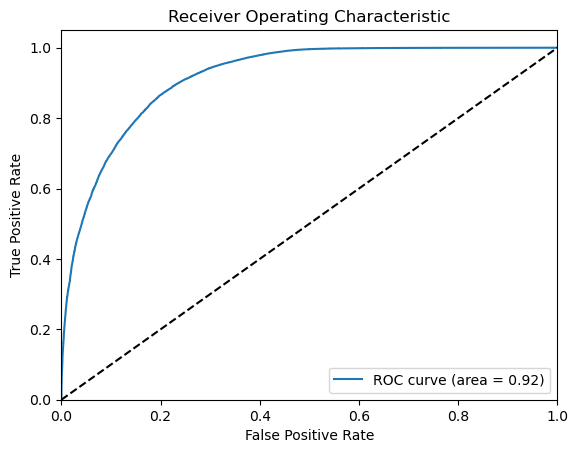

PR AUC: 0.972534744506099


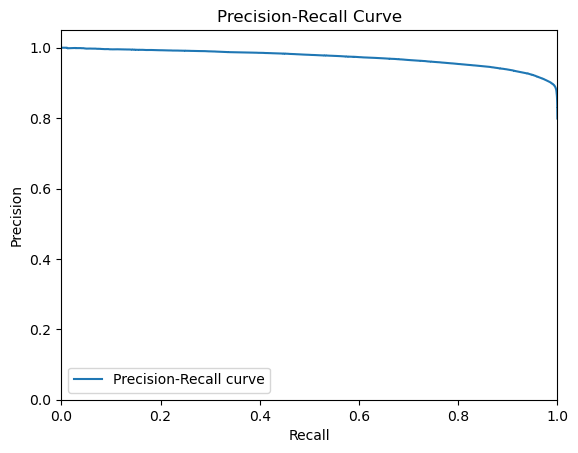

 92%|█████████▏| 11/12 [15:12<00:44, 44.35s/it]

[LightGBM] [Info] Number of positive: 377223, number of negative: 94989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1307
[LightGBM] [Info] Number of data points in the train set: 472212, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798842 -> initscore=1.379075
[LightGBM] [Info] Start training from score 1.379075
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Confusion Matrix:
 [[13786  9962]
 [ 1521 92785]]


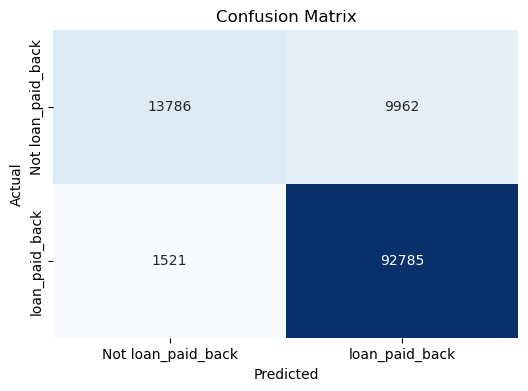


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.90      0.58      0.71     23748
    loan_paid_back       0.90      0.98      0.94     94306

          accuracy                           0.90    118054
         macro avg       0.90      0.78      0.82    118054
      weighted avg       0.90      0.90      0.89    118054

ROC-AUC: 0.9162353076709302


e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


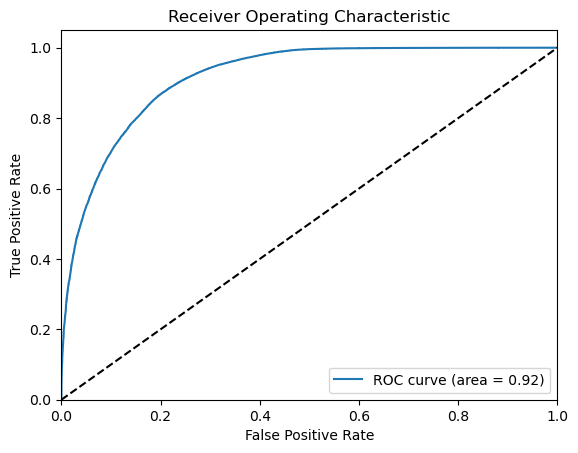

PR AUC: 0.9731216935183719


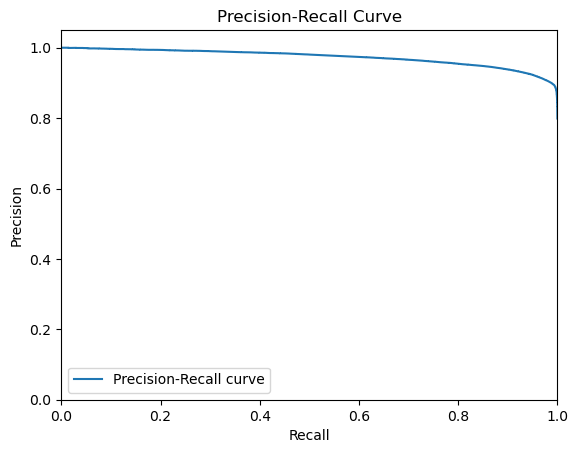

100%|██████████| 12/12 [15:15<00:00, 76.32s/it]


In [ ]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred  = model.predict(x_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)

    }

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not loan_paid_back','loan_paid_back']
                ,yticklabels=['Not loan_paid_back','loan_paid_back'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not loan_paid_back','loan_paid_back'],zero_division=0))

    y_pred_prob = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()
    

# GridSearchCV was commented to reduce execution time
# Best parameters were already obtained previously

In [ ]:
# from catboost import CatBoostClassifier
# from sklearn.model_selection import GridSearchCV
# model = CatBoostClassifier()
# param_grid = {
#     'n_estimators': [300, 100, 200],
#     'max_depth': [ 4, 8],
#     'random_state': [42,100,1],
#     'learning_rate': [0.1, 0.01, 0.05],   
# }
# graid= GridSearchCV(model, param_grid=param_grid, cv=5, n_jobs=-1)
# graid.fit(x_train, y_train)
# print(graid.best_params_)

0:	learn: 0.5809848	total: 108ms	remaining: 32.2s
1:	learn: 0.4980753	total: 189ms	remaining: 28.2s
2:	learn: 0.4371729	total: 271ms	remaining: 26.8s
3:	learn: 0.3915374	total: 367ms	remaining: 27.1s
4:	learn: 0.3588049	total: 461ms	remaining: 27.2s
5:	learn: 0.3356284	total: 539ms	remaining: 26.4s
6:	learn: 0.3169493	total: 622ms	remaining: 26s
7:	learn: 0.3031324	total: 703ms	remaining: 25.7s
8:	learn: 0.2928019	total: 793ms	remaining: 25.6s
9:	learn: 0.2852696	total: 872ms	remaining: 25.3s
10:	learn: 0.2790721	total: 947ms	remaining: 24.9s
11:	learn: 0.2742814	total: 1.02s	remaining: 24.5s
12:	learn: 0.2705134	total: 1.09s	remaining: 24.1s
13:	learn: 0.2677770	total: 1.16s	remaining: 23.7s
14:	learn: 0.2655225	total: 1.23s	remaining: 23.4s
15:	learn: 0.2639284	total: 1.3s	remaining: 23s
16:	learn: 0.2626497	total: 1.37s	remaining: 22.8s
17:	learn: 0.2614496	total: 2.55s	remaining: 39.9s
18:	learn: 0.2603517	total: 2.65s	remaining: 39.2s
19:	learn: 0.2595852	total: 2.73s	remaining: 3

0:	learn: 0.5809848	total: 182ms	remaining: 54.5s
1:	learn: 0.4980753	total: 236ms	remaining: 35.1s
2:	learn: 0.4371729	total: 283ms	remaining: 28s
3:	learn: 0.3915374	total: 332ms	remaining: 24.6s
4:	learn: 0.3588049	total: 385ms	remaining: 22.7s
5:	learn: 0.3356284	total: 442ms	remaining: 21.7s
6:	learn: 0.3169493	total: 508ms	remaining: 21.3s
7:	learn: 0.3031324	total: 566ms	remaining: 20.7s
8:	learn: 0.2928019	total: 628ms	remaining: 20.3s
9:	learn: 0.2852696	total: 693ms	remaining: 20.1s
10:	learn: 0.2790721	total: 751ms	remaining: 19.7s
11:	learn: 0.2742814	total: 809ms	remaining: 19.4s
12:	learn: 0.2705134	total: 871ms	remaining: 19.2s
13:	learn: 0.2677770	total: 941ms	remaining: 19.2s
14:	learn: 0.2655225	total: 1000ms	remaining: 19s
15:	learn: 0.2639284	total: 1.05s	remaining: 18.6s
16:	learn: 0.2626497	total: 1.1s	remaining: 18.4s
17:	learn: 0.2614496	total: 1.16s	remaining: 18.1s
18:	learn: 0.2603517	total: 1.21s	remaining: 17.8s
19:	learn: 0.2595852	total: 1.26s	remaining: 

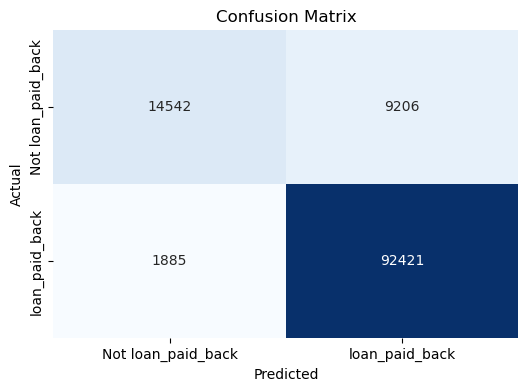


Classification Report:

                    precision    recall  f1-score   support

Not loan_paid_back       0.89      0.61      0.72     23748
    loan_paid_back       0.91      0.98      0.94     94306

          accuracy                           0.91    118054
         macro avg       0.90      0.80      0.83    118054
      weighted avg       0.90      0.91      0.90    118054

ROC-AUC: 0.9218529363096942


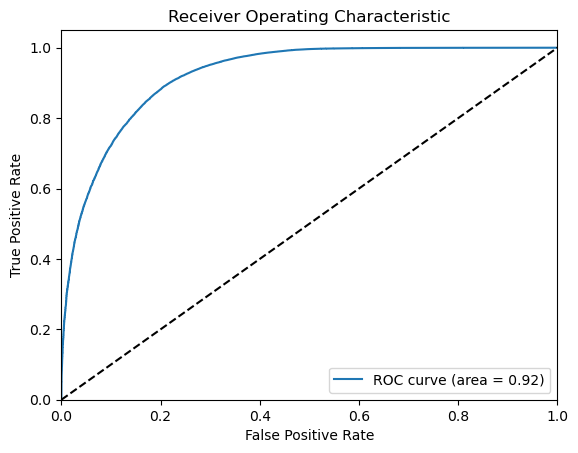

PR AUC: 0.9749709247385886


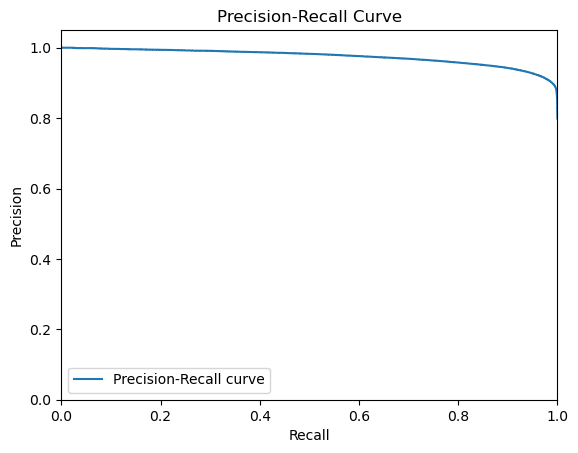

In [ ]:
from calendar import c
from catboost import CatBoostClassifier
model ={
    "CatBoost": CatBoostClassifier( random_state=42, max_depth=8,learning_rate=0.1,n_estimators=300)}
results = {}
for name, model in model.items():
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred  = model.predict(x_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)

    }

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not loan_paid_back','loan_paid_back']
                ,yticklabels=['Not loan_paid_back','loan_paid_back'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not loan_paid_back','loan_paid_back'],zero_division=0))

    y_pred_prob = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()


In [ ]:
from catboost import CatBoostClassifier
model = CatBoostClassifier( random_state=42, max_depth=8,learning_rate=0.1,n_estimators=300)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
with open('model.pkl', 'wb') as f:
        pickle.dump(model, f)

0:	learn: 0.5809848	total: 199ms	remaining: 59.5s
1:	learn: 0.4980753	total: 257ms	remaining: 38.3s
2:	learn: 0.4371729	total: 316ms	remaining: 31.3s
3:	learn: 0.3915374	total: 365ms	remaining: 27s
4:	learn: 0.3588049	total: 455ms	remaining: 26.8s
5:	learn: 0.3356284	total: 612ms	remaining: 30s
6:	learn: 0.3169493	total: 682ms	remaining: 28.5s
7:	learn: 0.3031324	total: 744ms	remaining: 27.1s
8:	learn: 0.2928019	total: 813ms	remaining: 26.3s
9:	learn: 0.2852696	total: 880ms	remaining: 25.5s
10:	learn: 0.2790721	total: 946ms	remaining: 24.8s
11:	learn: 0.2742814	total: 1s	remaining: 24.1s
12:	learn: 0.2705134	total: 1.07s	remaining: 23.7s
13:	learn: 0.2677770	total: 1.14s	remaining: 23.3s
14:	learn: 0.2655225	total: 1.21s	remaining: 23s
15:	learn: 0.2639284	total: 1.27s	remaining: 22.5s
16:	learn: 0.2626497	total: 1.37s	remaining: 22.8s
17:	learn: 0.2614496	total: 1.5s	remaining: 23.5s
18:	learn: 0.2603517	total: 1.55s	remaining: 23s
19:	learn: 0.2595852	total: 1.61s	remaining: 22.5s
20

# Project Summary
The dataset was cleaned and prepared successfully.
Exploratory Data Analysis helped discover important trends.
Visualizations made the data easier to understand.
Machine learning models were used to predict loan repayment.
# Final Insights
Education level and income affect repayment probability.
Logistic Regression performed well for prediction.
Data preprocessing improved model performance.
# Thank You